# Third-party production benchmarks

This notebook times one-shot k-NN, farthest-point sampling (FPS), and interpolation on `B = 1, 16`, `D = 2, 3`, and `N = queries = 10k, 20k, 30k, 40k, 50k`. k-NN and MLS use `k=4`; FPS selects 25%; interpolation has 64 channels. Every case uses float32.

Run this notebook with the existing **ml** kernel. GPU and CPU inputs are staged before timing; transfer and synthetic-data generation are excluded. Each measurement includes tree construction or per-call setup, warms up once, synchronizes GPU work, and reports the median of three calls. A warmup can populate torchbvh's FPS CUDA graph cache.

k-NN uses independent uniform point clouds and queries. FPS uses the same uniform clouds and fixed seed index zero. Interpolation uses a regular lattice so PyTorch `grid_sample` can operate on the same samples and queries as MLS. MLS local linear weights and grid_sample bilinear/trilinear weights are different; compare both latency and error against the analytic field, not output equality. SciPy's CPU KD-tree may internally convert float32 inputs to float64. [CuPy KDTree](https://docs.cupy.dev/en/stable/reference/generated/cupyx.scipy.spatial.KDTree.html) · [PyTorch grid_sample](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.grid_sample.html) · [fpsample QuickFPS](https://github.com/leonardodalinky/fpsample)

FPS outputs differ: torchbvh also returns assignment metadata, while the CPU methods return selected indices or points. QuickFPS can omit the requested starting point from its final sample; the quality table records this explicitly.

In [1]:
from pathlib import Path
import sys

root = Path.cwd()
if not (root / 'benchmarks' / 'third_party.py').exists():
    root = root.parent
if not (root / 'benchmarks' / 'third_party.py').exists():
    raise RuntimeError('Open this notebook from the repository root or examples directory')
sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from benchmarks.third_party import Case, cases, environment, run_case

print('Python:', sys.executable)
display(pd.Series(environment(), name='value').to_frame())

c:\Users\Rob.Hart-Villamil\Documents\python_envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: c:\Users\Rob.Hart-Villamil\Documents\python_envs\ml\Scripts\python.exe


,value
torch,2.10.0+cu126
cuda,12.6
gpu,NVIDIA RTX 3500 Ada Generation Laptop GPU
scipy,1.15.2
cupy,14.1.0
torch_cluster,1.6.3+pt210cu126
fpsample,1.0.2
torch_fpsample,0.1.0
torchbvh,0.3.0
dtype,float32


## Run the workload matrix

The default runs all 20 combinations and 10 methods per combination. For a quick trial, replace `selected_cases` with a short list such as `[Case(1, 2, 10_000)]`. Failures remain visible as rows with an error message.

In [2]:
selected_cases = cases()
warmup = 1
repeats = 3

rows = []
for index, case in enumerate(selected_cases, 1):
    print(f'[{index}/{len(selected_cases)}] B={case.batch}, D={case.dim}, N=M={case.points:,}', flush=True)
    rows.extend(run_case(case, warmup=warmup, repeats=repeats))
results = pd.DataFrame(rows)
display(results)

[1/20] B=1, D=2, N=M=10,000
[2/20] B=1, D=2, N=M=20,000
[3/20] B=1, D=2, N=M=30,000
[4/20] B=1, D=2, N=M=40,000
[5/20] B=1, D=2, N=M=50,000
[6/20] B=1, D=3, N=M=10,000
[7/20] B=1, D=3, N=M=20,000
[8/20] B=1, D=3, N=M=30,000
[9/20] B=1, D=3, N=M=40,000
[10/20] B=1, D=3, N=M=50,000
[11/20] B=16, D=2, N=M=10,000
[12/20] B=16, D=2, N=M=20,000
[13/20] B=16, D=2, N=M=30,000
[14/20] B=16, D=2, N=M=40,000
[15/20] B=16, D=2, N=M=50,000
[16/20] B=16, D=3, N=M=10,000
[17/20] B=16, D=3, N=M=20,000
[18/20] B=16, D=3, N=M=30,000
[19/20] B=16, D=3, N=M=40,000
[20/20] B=16, D=3, N=M=50,000


,operation,method,batch,dim,points,queries,samples,channels,status,error,latency_ms,max_distance_error,neighbor_match_fraction,seed_included_fraction,coverage_radius,mean_coverage_distance,rmse,max_abs_error
0,knn,torchbvh,1,2,10000,10000,NaN,NaN,ok,None,0.6722,1.301193e-09,1.0,NaN,NaN,NaN,NaN,NaN
1,knn,scipy_cKDTree,1,2,10000,10000,NaN,NaN,ok,None,7.4888,0.000000e+00,1.0,NaN,NaN,NaN,NaN,NaN
2,knn,torch_cluster,1,2,10000,10000,NaN,NaN,ok,None,5.0552,1.301193e-09,1.0,NaN,NaN,NaN,NaN,NaN
3,knn,cupy_KDTree,1,2,10000,10000,NaN,NaN,ok,None,7.4002,3.469447e-18,1.0,NaN,NaN,NaN,NaN,NaN
4,fps,torchbvh_exact,1,2,10000,10000,2500.0,NaN,ok,None,15.0272,NaN,NaN,1.0000,0.013465,0.005971,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,fps,torchbvh_approx,16,3,50000,50000,12500.0,NaN,ok,None,129.4000,NaN,NaN,1.0000,0.031608,0.015712,NaN,NaN
196,fps,fpsample_h7,16,3,50000,50000,12500.0,NaN,ok,None,5055.3247,NaN,NaN,0.3125,0.031575,0.015701,NaN,NaN
197,fps,torch_fpsample_h7,16,3,50000,50000,12500.0,NaN,ok,None,578.3310,NaN,NaN,1.0000,0.031556,0.015704,NaN,NaN
198,interpolation,torchbvh_mls,16,3,50000,50000,NaN,64.0,ok,None,30.0963,NaN,NaN,NaN,NaN,NaN,0.005135,0.028145


## Timing results

Latency is median wall-clock milliseconds per one-shot call. Rows marked `failed` are retained so unsupported shapes, runtime failures, and validation failures are visible.

0 failed rows out of 200


,operation,method,batch,dim,points,error


method                          cupy_KDTree  fpsample_h7  grid_sample  \
operation     batch dim points                                          
fps           1     2   10000           NaN       10.888          NaN   
                        20000           NaN       21.895          NaN   
                        30000           NaN       42.039          NaN   
                        40000           NaN       64.510          NaN   
                        50000           NaN       89.064          NaN   
                    3   10000           NaN       24.229          NaN   
                        20000           NaN       68.542          NaN   
                        30000           NaN      118.119          NaN   
                        40000           NaN      182.676          NaN   
                        50000           NaN      260.186          NaN   
              16    2   10000           NaN      213.807          NaN   
                        20000           NaN      408.892          NaN   
                        30000           NaN      805.516          NaN   
                        40000           NaN     1169.270          NaN   
                        50000           NaN     1679.911          NaN   
                    3   10000           NaN      471.959          NaN   
                        20000           NaN     1340.073          NaN   
                        30000           NaN     2291.165          NaN   
                        40000           NaN     3541.949          NaN   
                        50000           NaN     5055.325          NaN   
interpolation 1     2   10000           NaN          NaN        0.108   
                        20000           NaN          NaN        0.149   
                        30000           NaN          NaN        0.187   
                        40000           NaN          NaN        0.253   
                        50000           NaN          NaN        0.338   
                    3   10000           NaN          NaN        0.118   
                        20000           NaN          NaN        0.173   
                        30000           NaN          NaN        0.276   
                        40000           NaN          NaN        0.387   
                        50000           NaN          NaN        0.521   
              16    2   10000           NaN          NaN        0.883   
                        20000           NaN          NaN        2.201   
                        30000           NaN          NaN        3.361   
                        40000           NaN          NaN        4.563   
                        50000           NaN          NaN        5.891   
                    3   10000           NaN          NaN        5.741   
                        20000           NaN          NaN        3.223   
                        30000           NaN          NaN        5.855   
                        40000           NaN          NaN        7.807   
                        50000           NaN          NaN        9.883   
knn           1     2   10000         7.400          NaN          NaN   
                        20000        10.579          NaN          NaN   
                        30000        13.085          NaN          NaN   
                        40000        14.782          NaN          NaN   
                        50000        15.615          NaN          NaN   
                    3   10000         9.587          NaN          NaN   
                        20000        16.287          NaN          NaN   
                        30000        22.885          NaN          NaN   
                        40000        33.686          NaN          NaN   
                        50000        37.526          NaN          NaN   
              16    2   10000        91.797          NaN          NaN   
                        20000       123.481          NaN          NaN   
                        30000       155.576          NaN  

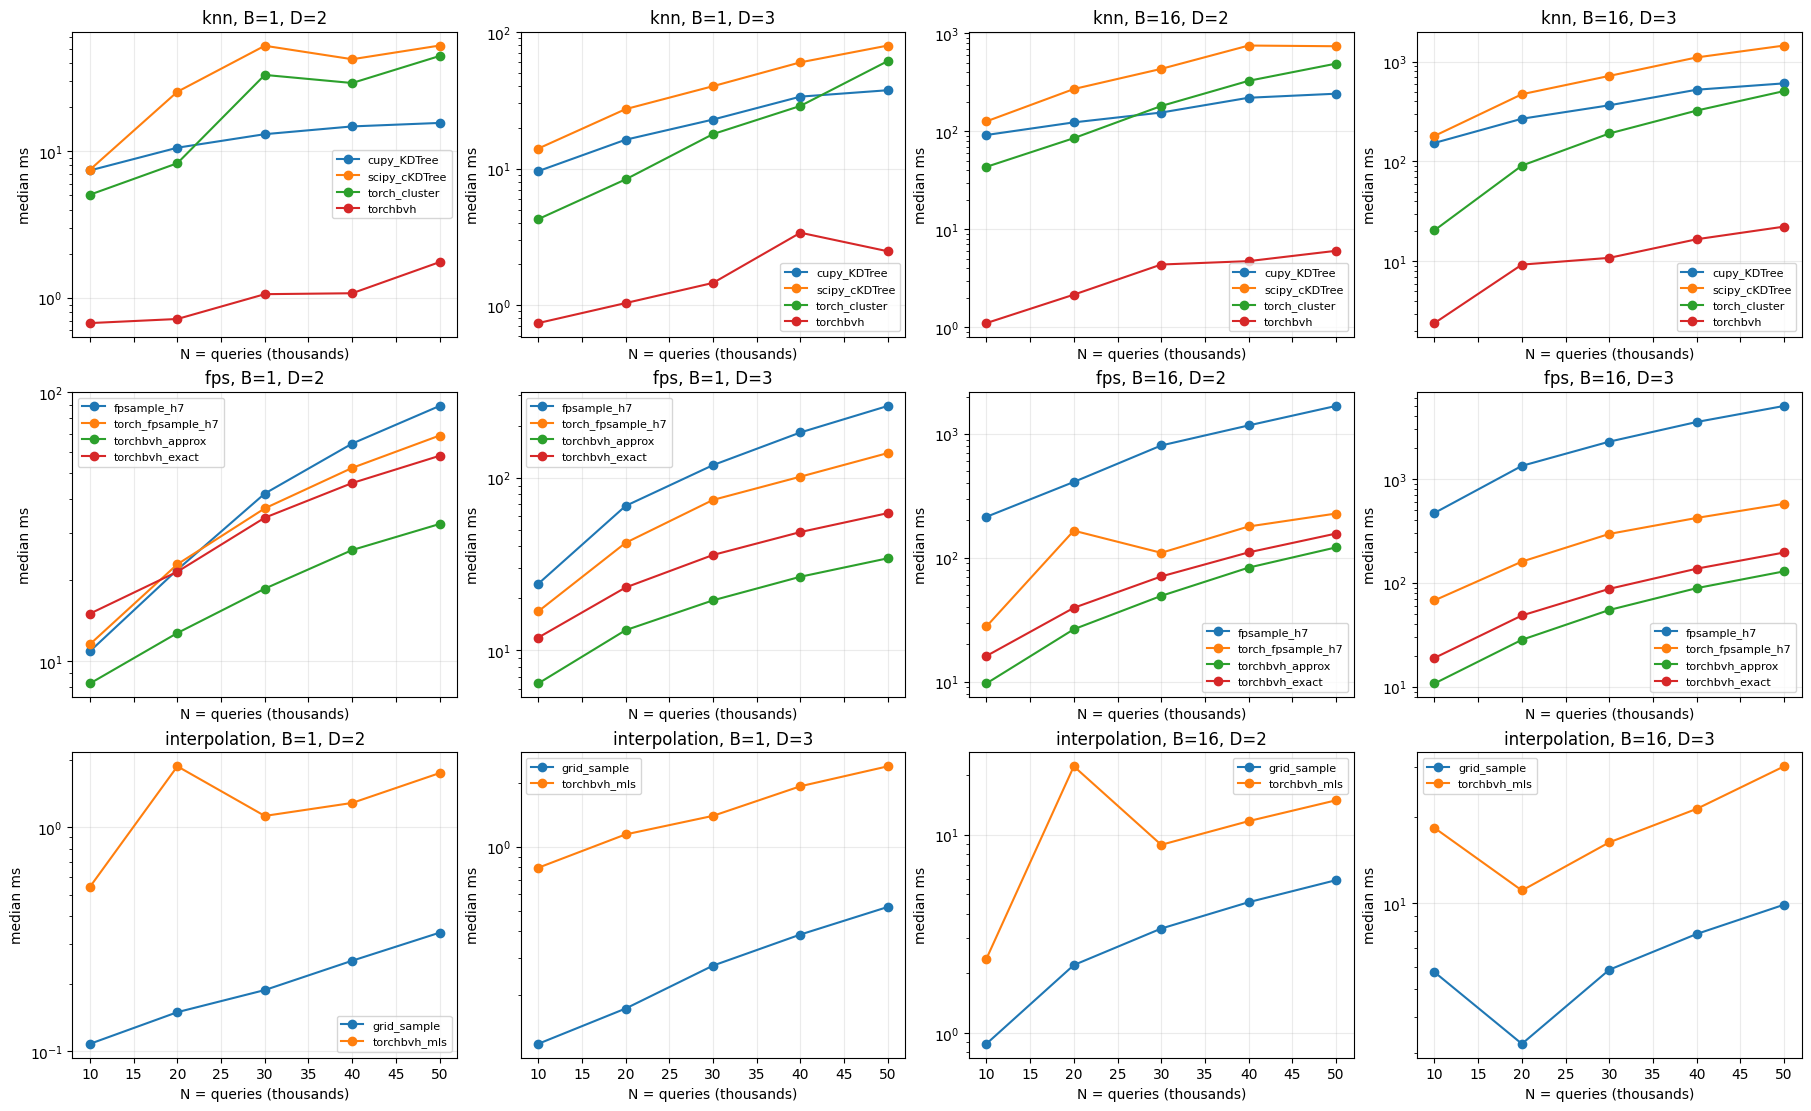

In [3]:
failures = results.loc[results.status != 'ok', ['operation', 'method', 'batch', 'dim', 'points', 'error']]
print(f'{len(failures)} failed rows out of {len(results)}')
display(failures)
display(results.pivot_table(index=['operation', 'batch', 'dim', 'points'], columns='method', values='latency_ms', aggfunc='first').round(3))

fig, axes = plt.subplots(3, 4, figsize=(18, 11), sharex=True, layout='constrained')
for row, operation in enumerate(('knn', 'fps', 'interpolation')):
    for col, (batch, dim) in enumerate(((1, 2), (1, 3), (16, 2), (16, 3))):
        ax = axes[row, col]
        subset = results[(results.operation == operation) & (results.batch == batch) & (results.dim == dim) & (results.status == 'ok')]
        for method, group in subset.groupby('method'):
            group = group.sort_values('points')
            ax.plot(group.points / 1000, group.latency_ms, marker='o', label=method)
        ax.set(title=f'{operation}, B={batch}, D={dim}', xlabel='N = queries (thousands)', ylabel='median ms', yscale='log')
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
plt.show()

## Output quality

k-NN distances are checked against SciPy on the first 256 queries per batch; `neighbor_match_fraction` counts queries whose four distances agree within `1e-4`. FPS reports the fraction of batches containing requested seed 0; coverage is the largest and mean distance from a source point to its nearest selected anchor. Interpolation RMSE and maximum absolute error use the known smooth 64-channel field. These checks run outside the timed region.

In [ ]:
quality_columns = ['operation', 'method', 'batch', 'dim', 'points', 'status', 'max_distance_error', 'neighbor_match_fraction', 'seed_included_fraction', 'coverage_radius', 'mean_coverage_distance', 'rmse', 'max_abs_error']
display(results.reindex(columns=quality_columns).round(6))